# Úkol 6


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

warnings.filterwarnings('ignore')


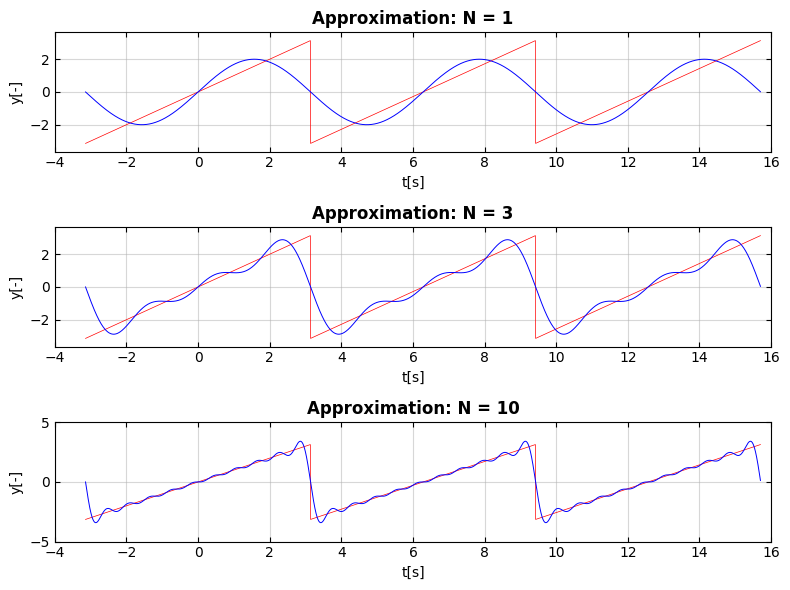

In [2]:
T = 2 * np.pi
w0 = 2 * np.pi / T
fs = 1000
t_start = -np.pi
t_end = 5 * np.pi
t = np.linspace(t_start, t_end, int((t_end - t_start) * fs / (2*np.pi)), endpoint=False)

def y_func(t_val):
    return ((t_val + np.pi) % (2 * np.pi)) - np.pi

y_ideal = y_func(t)

N_max = 10
a = np.zeros(N_max + 1)
b = np.zeros(N_max + 1)

a[0] = (2/T) * quad(lambda x: y_func(x), -np.pi, np.pi)[0]
b[0] = np.nan

for n in range(1, N_max + 1):
    a[n] = (2/T) * quad(lambda x: y_func(x) * np.cos(n * w0 * x), -np.pi, np.pi)[0]
    b[n] = (2/T) * quad(lambda x: y_func(x) * np.sin(n * w0 * x), -np.pi, np.pi)[0]

N_vals = [1, 3, 10]
plt.figure(figsize=(8, 6))

for i, N in enumerate(N_vals):
    ax = plt.subplot(3, 1, i+1)
    
    y_approx = np.ones_like(t) * (a[0] / 2)
    for n in range(1, N + 1):
        y_approx += a[n] * np.cos(n * w0 * t) + b[n] * np.sin(n * w0 * t)
        
    ax.plot(t, y_ideal, 'r-', linewidth=0.5)
    ax.plot(t, y_approx, 'b-', linewidth=0.7)
    ax.set_title(f'Approximation: N = {N}', fontweight='bold')
    ax.set_xlabel('t[s]')
    ax.set_ylabel('y[-]')
    ax.grid(True, alpha=0.5)
    ax.set_xlim(-4, 16)
    ax.set_xticks(np.arange(-4, 17, 2))
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    if N == 10:
        ax.set_ylim(-5, 5)
        ax.set_yticks(np.arange(-5, 6, 5))
    else:
        ax.set_ylim([-np.pi-0.5, np.pi+0.5])

plt.tight_layout()
plt.show()


In [3]:
df_real = pd.DataFrame({
    'n': range(N_max + 1),
    'An': a,
    'Bn': b
})
display(df_real.style.format({'An': '{:.4e}', 'Bn': '{:.4f}'}).hide(axis="index"))


n,An,Bn
0,2.2722e-16,nan
1,-4.9755e-17,2.0000
2,-2.0913e-17,-1.0000
3,-5.3074e-17,0.6667
4,-5.1477e-17,-0.5000
5,-8.5431e-18,0.4000
6,9.3707e-17,-0.3333
7,-5.6517e-17,0.2857
8,4.5884e-17,-0.2500
9,2.0321e-17,0.2222


In [4]:
n_complex = np.arange(-N_max, N_max + 1)
c_n = np.zeros(len(n_complex), dtype=complex)

for i, n in enumerate(n_complex):
    if n == 0:
        c_n[i] = a[0] / 2
    elif n > 0:
        c_n[i] = (a[n] - 1j * b[n]) / 2
    else:
        n_pos = -n
        c_n[i] = np.conj((a[n_pos] - 1j * b[n_pos]) / 2)

df_complex = pd.DataFrame({
    'n': n_complex,
    'Re_Cn': np.real(c_n),
    'Im_Cn': np.imag(c_n),
    'Magnitude': np.abs(c_n),
    'Phase': np.angle(c_n)
})

df_complex.loc[np.abs(df_complex['Re_Cn']) < 1e-15, 'Re_Cn'] = df_complex['Re_Cn'] 
display(df_complex.style.format({
    'Re_Cn': '{:.4e}', 
    'Im_Cn': '{:.4f}',
    'Magnitude': '{:.4f}',
    'Phase': '{:.4f}'
}).hide(axis="index"))


n,Re_Cn,Im_Cn,Magnitude,Phase
-10,-1.1944e-17,-0.1000,0.1000,-1.5708
-9,1.0160e-17,0.1111,0.1111,1.5708
-8,2.2942e-17,-0.1250,0.1250,-1.5708
-7,-2.8258e-17,0.1429,0.1429,1.5708
-6,4.6854e-17,-0.1667,0.1667,-1.5708
-5,-4.2715e-18,0.2000,0.2000,1.5708
-4,-2.5738e-17,-0.2500,0.2500,-1.5708
-3,-2.6537e-17,0.3333,0.3333,1.5708
-2,-1.0457e-17,-0.5000,0.5000,-1.5708
-1,-2.4878e-17,1.0000,1.0000,1.5708


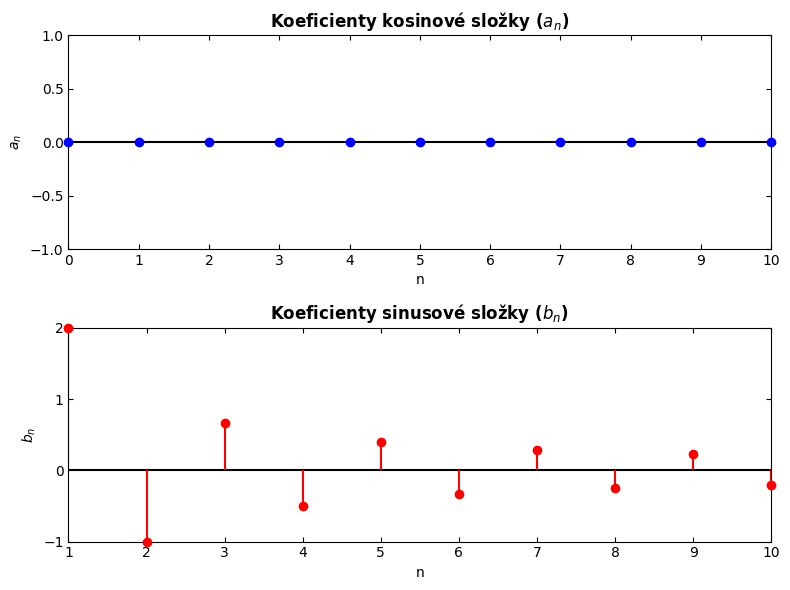

In [5]:
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
markerline, stemlines, baseline = plt.stem(range(N_max + 1), a, linefmt='b-', markerfmt='bo', basefmt='k-')
markerline.set_clip_on(False)
markerline.set_zorder(3)
stemlines.set_zorder(2)
baseline.set_zorder(1)
plt.title(r'Koeficienty kosinové složky ($a_n$)', fontweight='bold')
plt.xlabel('n')
plt.ylabel(r'$a_n$')
plt.xlim([0, 10])
plt.ylim([-1, 1])
plt.xticks(range(11))
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(range(1, N_max + 1), b[1:], linefmt='r-', markerfmt='ro', basefmt='k-')
markerline.set_clip_on(False)
markerline.set_zorder(3)
stemlines.set_zorder(2)
baseline.set_zorder(1)
plt.title(r'Koeficienty sinusové složky ($b_n$)', fontweight='bold')
plt.xlabel('n')
plt.ylabel(r'$b_n$')
plt.xlim([1, 10])
plt.ylim([-1, 2])
plt.xticks(range(1, 11))
plt.yticks(range(-1, 3, 1))
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)


plt.tight_layout()
plt.show()


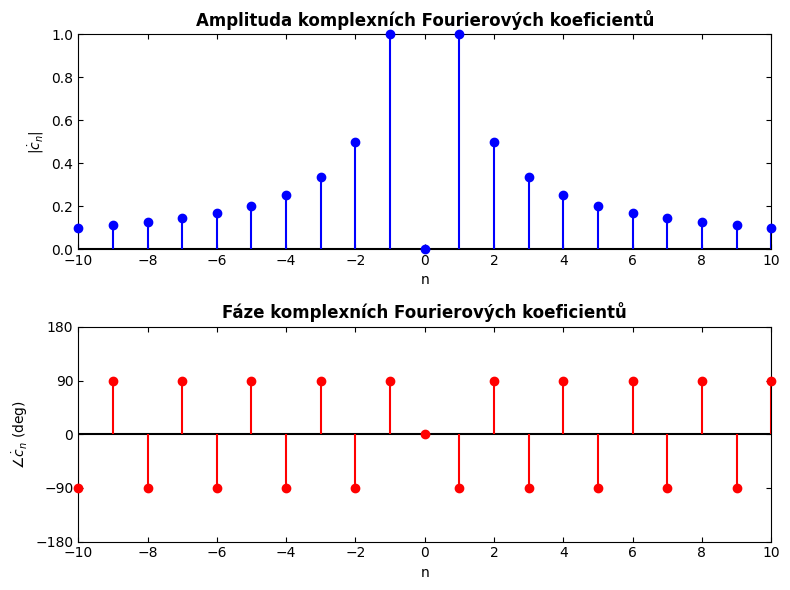

In [6]:
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
markerline, stemlines, baseline = plt.stem(n_complex, np.abs(c_n), linefmt='b-', markerfmt='bo', basefmt='k-')
markerline.set_clip_on(False)
markerline.set_zorder(3)
stemlines.set_zorder(2)
baseline.set_zorder(1)

plt.title('Amplituda komplexních Fourierových koeficientů', fontweight='bold')
plt.xlabel('n')
plt.ylabel(r'$|\dot{c}_n|$')
plt.xticks(range(-10, 11, 2))
plt.xlim(-10, 10)
plt.ylim(0, 1) 
plt.tick_params(direction='in', top=True, right=True, bottom=True, left=True)

plt.subplot(2, 1, 2)
phase_deg = np.angle(c_n, deg=True)
markerline2, stemlines2, baseline2 = plt.stem(n_complex, phase_deg, linefmt='r-', markerfmt='ro', basefmt='k-')
markerline2.set_clip_on(False)
markerline2.set_zorder(3)
stemlines2.set_zorder(2)
baseline2.set_zorder(1)

plt.title('Fáze komplexních Fourierových koeficientů', fontweight='bold')
plt.xlabel('n')
plt.ylabel(r'$\angle \dot{c}_n$ (deg)')
plt.yticks([-180, -90, 0, 90, 180])
plt.xticks(range(-10, 11, 2))
plt.xlim(-10, 10)
plt.ylim(-180, 180) 
plt.tick_params(direction='in', top=True, right=True, bottom=True, left=True)

plt.tight_layout()
plt.show()


## Komentář
Nejprve jsem importoval nezbytné knihovny. Následně jsem definoval základní parametry signálu: opakovací periodu $T = 2\pi$ a základní úhlovou frekvenci $\omega_0 = 1$. Poté jsem vytvořil funkci reprezentující původní signál $y(t) = t$ periodicky rozšířený na interval $\langle -\pi, 5\pi \rangle$, aby pokryl přesně tři periody. Vzorkovací frekvenci $f_s = 1000$ Hz jsem zvolil dostatečně vysokou, aby zajistila plynulé a přesné vykreslení všech následných průběhů.

Algoritmus pro výpočet koeficientů Fourierovy řady jsem realizoval pomocí numerické integrace funkce `scipy.integrate.quad` přes jednu periodu. Následně jsem vytvořil funkci pro syntézu signálu, která na základě těchto koeficientů provádí aproximaci $y(t)$ postupně pro $N = 1, 3, 10$.

Pro názornou vizualizaci jsem vygeneroval první tři grafy zobrazující průběhy původního a aproximovaného signálu. Vizuálním porovnáním jsem potvrdil, že s rostoucím počtem harmonických složek N se aproximovaný průběh stále více blíží ideálnímu pilovitému signálu, přičemž je zřetelně pozorovatelný Gibbsův jev v bodech nespojitosti.

Pro detailní analýzu jsem vypočtené reálné koeficienty $a_n$, $b_n$ a odvozené komplexní koeficienty $\dot{c}_n$ (včetně jejich velikosti a fáze) formátoval do dvou přehledných tabulek pomocí knihovny `pandas`. První tabulka zobrazuje hodnoty reálných koeficientů $a_n$ a $b_n$, druhá tabulka pak přehledně verifikuje odvozené komplexní koeficienty $\dot{c}_n$. Druhá sada grafů znázorňuje koeficienty reálné Fourierovy řady (nulové $a_n$ a klesající $b_n$). Třetí sada grafů poté znázorňuje amplitudové a fázové spektrum komplexních koeficientů $\dot{c}_n$. Fázi jsem pro lepší čitelnost v grafu převedl do stupňů, čímž jsem ověřil správnost frekvenční reprezentace signálu.
